In [18]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
project_path = os.getcwd()
print('project path = ' , project_path)

file_path = project_path + '/Hotel Reservations.xlsx'
print('file path =' , file_path)

df = pd.read_excel(file_path)
print(df)

project path =  /Users/pulkit/Desktop/major project
file path = /Users/pulkit/Desktop/major project/Hotel Reservations.xlsx
      Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0       INN00001             2               0                     1   
1       INN00002             2               0                     2   
2       INN00003             1               0                     2   
3       INN00004             2               0                     0   
4       INN00005             2               0                     1   
...          ...           ...             ...                   ...   
36270   INN36271             3               0                     2   
36271   INN36272             2               0                     1   
36272   INN36273             2               0                     2   
36273   INN36274             2               0                     0   
36274   INN36275             2               0                     1   

       no_o

In [20]:

# =========================
# 3. DATA CLEANING
# =========================
# Drop useless column
if 'Booking_ID' in df.columns:
    df.drop('Booking_ID', axis=1, inplace=True)
    
# Feature engineering
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']


# =========================
# 5. HANDLE CATEGORICAL DATA
# =========================
categorical_cols = [
    'type_of_meal_plan',
    'room_type_reserved',
    'market_segment_type'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# =========================
# 6. DEFINE FEATURES & TARGET
# =========================
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 9. FIND BEST K VALUE
# =========================
best_k = 1
best_acc = 0

for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    
    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best K:", best_k)
print("Best Accuracy:", best_acc)


# Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best K: 1
Best Accuracy: 0.8534803583735355
Accuracy: 0.8493452791178497
Confusion Matrix:
 [[1799  617]
 [ 476 4363]]

Classification Report:
               precision    recall  f1-score   support

    Canceled       0.79      0.74      0.77      2416
Not_Canceled       0.88      0.90      0.89      4839

    accuracy                           0.85      7255
   macro avg       0.83      0.82      0.83      7255
weighted avg       0.85      0.85      0.85      7255



In [21]:
# =========================
# 12. TEST ON NEW DATA
# =========================
# Example new booking
new_data = pd.DataFrame({
    'no_of_adults': [2],
    'no_of_children': [0],
    'no_of_weekend_nights': [1],
    'no_of_week_nights': [2],
    'lead_time': [50],
    'avg_price_per_room': [120],
    'repeated_guest': [0]
})

# Feature engineering
new_data['total_nights'] = new_data['no_of_weekend_nights'] + new_data['no_of_week_nights']

# Convert to dummies
new_data = pd.get_dummies(new_data)

# Match columns with training data
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Scale
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = knn.predict(new_data_scaled)

# Output
if prediction[0] == 1:
    print("\nPrediction: Booking will be Canceled ❌")
else:
    print("\nPrediction: Booking will NOT be Canceled ✅")


Prediction: Booking will NOT be Canceled ✅


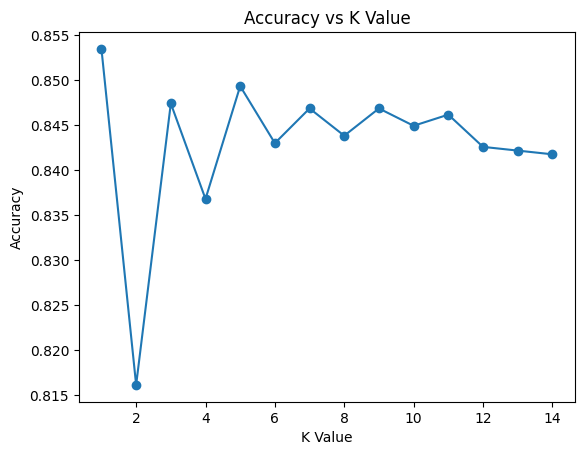

In [22]:
#accuracy vs K
import matplotlib.pyplot as plt

k_values = []
accuracies = []

for k in range(1, 15):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    
    k_values.append(k)
    accuracies.append(acc)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.show()

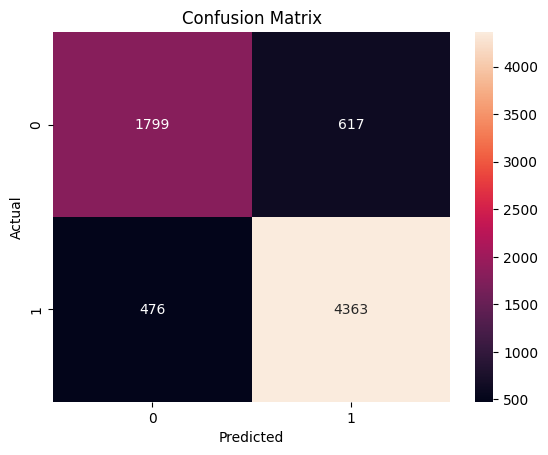

In [23]:
#confusion matrix heatmap
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

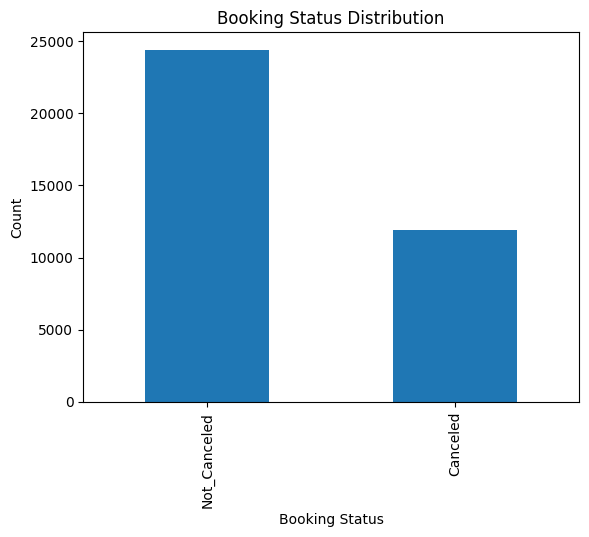

In [24]:
#booking status distribution
df['booking_status'].value_counts().plot(kind='bar')

plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.title("Booking Status Distribution")
plt.show()

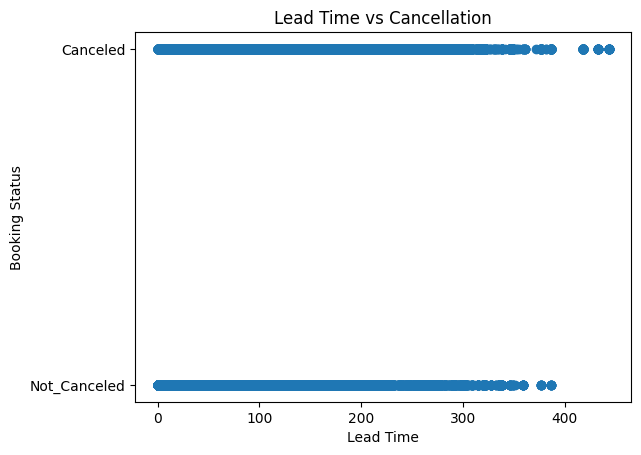

In [25]:
#lead time vs cancellation
plt.figure()
plt.scatter(df['lead_time'], df['booking_status'])
plt.xlabel("Lead Time")
plt.ylabel("Booking Status")
plt.title("Lead Time vs Cancellation")
plt.show()